# Suicide Detection ML Pipeline
This notebook loads Suicide_Detection.csv and performs EDA, feature engineering, TF‑IDF modeling, and performance comparison.

## 1. Import Libraries

In [26]:
import pandas as pd
import numpy as np
import re, string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

## 2. Load Dataset

In [27]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Suicide_Detection.csv', index_col=0)
# df = pd.read_csv("Suicide_Detection.csv")
df.columns = ["text", "label"]
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,text,label
2,Ex Wife Threatening SuicideRecently I left my ...,suicide
3,Am I weird I don't get affected by compliments...,non-suicide
4,Finally 2020 is almost over... So I can never ...,non-suicide
8,i need helpjust help me im crying so hard,suicide
9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


## 3. Clean Text

In [28]:
def normalize(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text.strip()

df["clean_text"] = df["text"].apply(normalize)
df.head()

,text,label,clean_text
2,Ex Wife Threatening SuicideRecently I left my ...,suicide,ex wife threatening suiciderecently i left my ...
3,Am I weird I don't get affected by compliments...,non-suicide,am i weird i dont get affected by compliments ...
4,Finally 2020 is almost over... So I can never ...,non-suicide,finally 2020 is almost over so i can never hea...
8,i need helpjust help me im crying so hard,suicide,i need helpjust help me im crying so hard
9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide,i’m so losthello my name is adam 16 and i’ve b...


## 4. EDA: Length Features

In [29]:
df["char_length"] = df["clean_text"].str.len()
df["word_length"] = df["clean_text"].str.split().apply(len)

df.groupby("label")["word_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
non-suicide,116037.0,60.674802,134.110831,0.0,18.0,31.0,60.0,8220.0
suicide,116037.0,202.343796,254.904606,0.0,60.0,127.0,250.0,9684.0


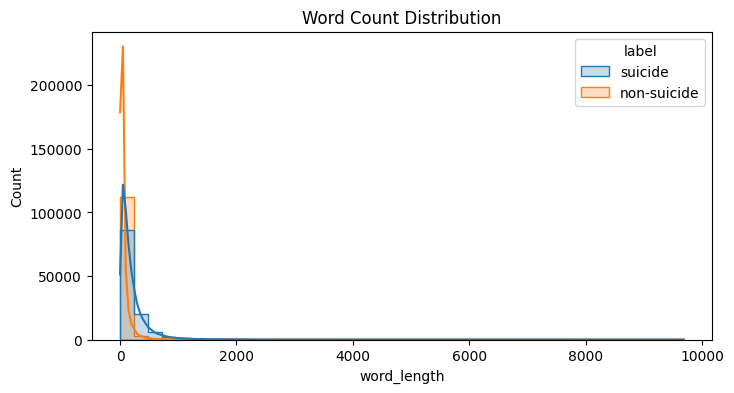

In [30]:
plt.figure(figsize=(8,4))
sns.histplot(df, x="word_length", hue="label", bins=40, element="step", kde=True)
plt.title("Word Count Distribution")
plt.show()

## 5. Token Frequency Analysis

## Top Token Frequency Bar Chart


Mounted at /content/drive


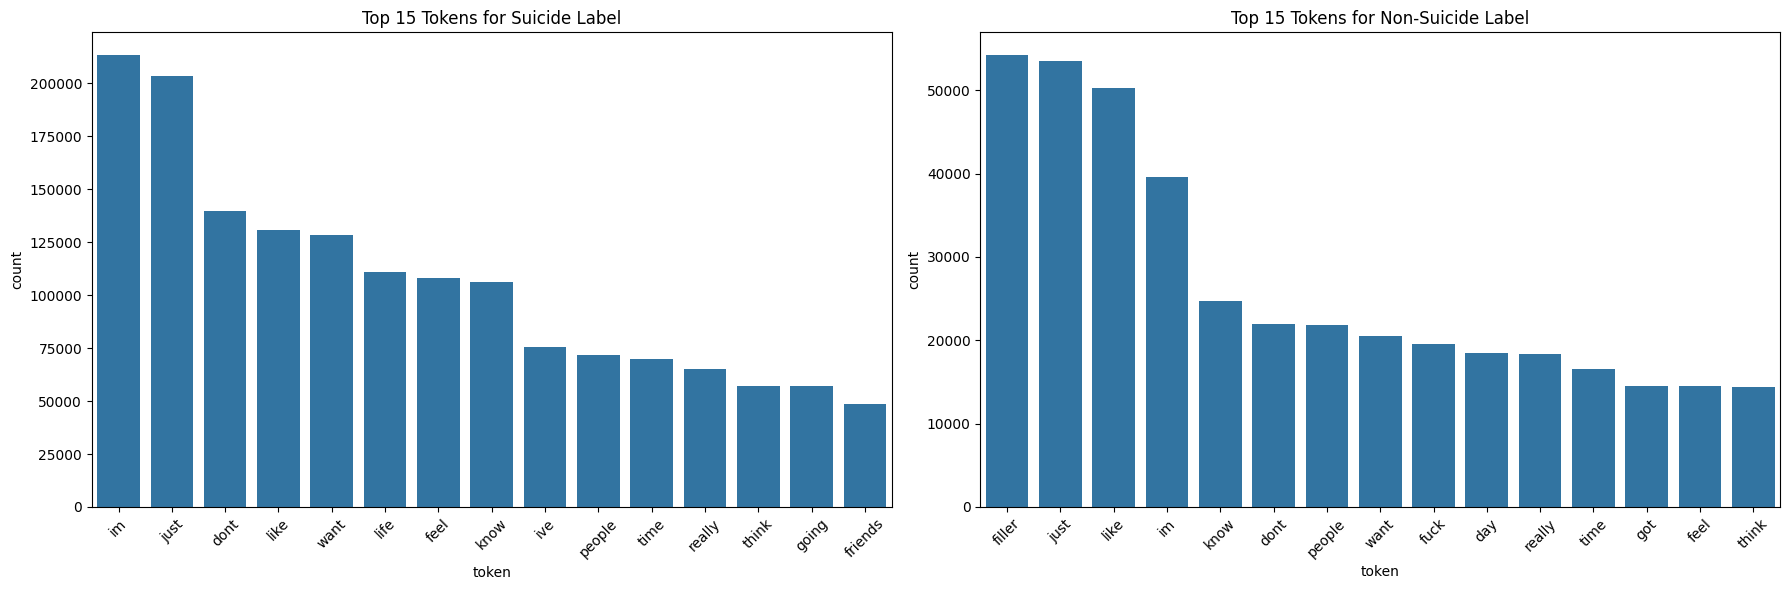

In [31]:
import pandas as pd
import numpy as np
import re, string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from google.colab import drive

# Re-mount Google Drive to ensure access
drive.mount('/content/drive', force_remount=True)

# Re-load dataset and preprocess `df` to ensure it's available
df = pd.read_csv('/content/drive/MyDrive/Suicide_Detection.csv', index_col=0)
df.columns = ["text", "label"]

def normalize(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    return text.strip()

df["clean_text"] = df["text"].apply(normalize)

cv = CountVectorizer(stop_words="english")
X_counts = cv.fit_transform(df["clean_text"])
tokens = np.array(cv.get_feature_names_out())

def top_tokens(label, n=20):
    mask = df["label"] == label
    freq = X_counts[mask.values].sum(axis=0).A1
    idx = freq.argsort()[::-1][:n]
    return pd.DataFrame({"token": tokens[idx], "count": freq[idx]})

suicide_top_tokens = top_tokens("suicide", n=15)
non_suicide_top_tokens = top_tokens("non-suicide", n=15)

suicide_top_tokens["label"] = "suicide"
non_suicide_top_tokens["label"] = "non-suicide"

combined_top_tokens = pd.concat([suicide_top_tokens, non_suicide_top_tokens])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x="token", y="count", data=combined_top_tokens[combined_top_tokens["label"] == "suicide"], ax=axes[0])
axes[0].set_title("Top 15 Tokens for Suicide Label")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x="token", y="count", data=combined_top_tokens[combined_top_tokens["label"] == "non-suicide"], ax=axes[1])
axes[1].set_title("Top 15 Tokens for Non-Suicide Label")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [32]:
cv = CountVectorizer(stop_words="english")
X_counts = cv.fit_transform(df["clean_text"])
tokens = np.array(cv.get_feature_names_out())

def top_tokens(label, n=20):
    mask = df["label"] == label
    freq = X_counts[mask.values].sum(axis=0).A1
    idx = freq.argsort()[::-1][:n]
    return pd.DataFrame({"token": tokens[idx], "count": freq[idx]})

top_tokens("suicide", 15)

,token,count
0,im,213466
1,just,203484
2,dont,139932
3,like,131021
4,want,128286
5,life,110848
6,feel,107942
7,know,106346
8,ive,75380
9,people,71895


## 6. Sentiment‑like Lexical Features

In [33]:
neg_words = {"suicide","kill","die","cut","hurt","hopeless","worthless","end","empty"}
pos_words = {"love","happy","great","hope","enjoy","friends","support","smile","proud"}

def lex_features(text):
    ws = text.split()
    pos = sum(w in pos_words for w in ws)
    neg = sum(w in neg_words for w in ws)
    return pd.Series([pos, neg, pos-neg])

df[["pos_score","neg_score","sent_balance"]] = df["clean_text"].apply(lex_features)
df.groupby("label")[["pos_score","neg_score","sent_balance"]].mean()

,pos_score,neg_score,sent_balance
label,,,
non-suicide,0.310909,0.103183,0.207727
suicide,1.176323,1.495954,-0.319631


## Sentiment Balance Score Box Plot



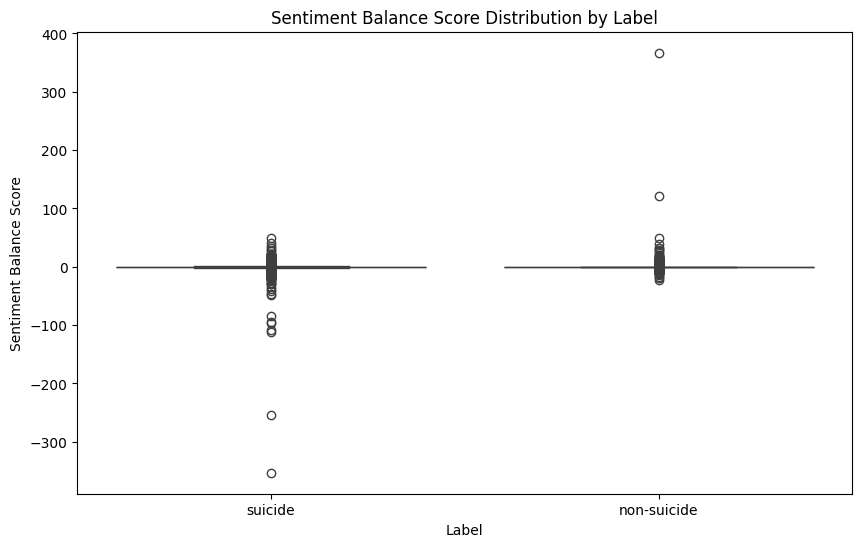

In [34]:
neg_words = {"suicide","kill","die","cut","hurt","hopeless","worthless","end","empty"}
pos_words = {"love","happy","great","hope","enjoy","friends","support","smile","proud"}

def lex_features(text):
    ws = text.split()
    pos = sum(w in pos_words for w in ws)
    neg = sum(w in neg_words for w in ws)
    return pd.Series([pos, neg, pos-neg])

df[["pos_score","neg_score","sent_balance"]] = df["clean_text"].apply(lex_features)

plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='sent_balance', data=df)
plt.title('Sentiment Balance Score Distribution by Label')
plt.xlabel('Label')
plt.ylabel('Sentiment Balance Score')
plt.show()

## 7. Train/Test Split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"],
    test_size=0.2, stratify=df["label"], random_state=42
)

#8. Glove embeddings
```
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip
```

In [36]:
import os

if not os.path.exists("glove.6B.zip"):
    !wget http://nlp.stanford.edu/data/glove.6B.zip
    !unzip glove.6B.zip
    print("GloVe embeddings downloaded and unzipped.")
else:
    print("GloVe embeddings already present.")

--2025-12-18 11:16:06--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-12-18 11:16:06--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-12-18 11:16:06--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [37]:
embedding_dim = 100

word_to_vec_map = {}
with open(f'glove.6B.{embedding_dim}d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vec = np.asarray(values[1:], dtype='float32')
        word_to_vec_map[word] = vec

print(f"Loaded {len(word_to_vec_map)} word vectors.")

def get_sentence_embedding(text, word_to_vec_map, embedding_dim):
    words = str(text).lower().split() # Token+ lowercase
    embedding = np.zeros(embedding_dim)
    num_words = 0
    for word in words:
        if word in word_to_vec_map:
            embedding += word_to_vec_map[word]
            num_words += 1
    if num_words > 0:
        return embedding / num_words
    else:
        return embedding #zero for null sentences or unknown words


X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"],
    test_size=0.2, stratify=df["label"], random_state=42
)

X_train_glove = np.array([get_sentence_embedding(text, word_to_vec_map, embedding_dim) for text in X_train])
X_test_glove = np.array([get_sentence_embedding(text, word_to_vec_map, embedding_dim) for text in X_test])

print(f"X_train_glove shape: {X_train_glove.shape}")
print(f"X_test_glove shape: {X_test_glove.shape}")

Loaded 400000 word vectors.
X_train_glove shape: (185659, 100)
X_test_glove shape: (46415, 100)


## 9. Models: Logistic Regression and Random Forest

In [38]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    model.fit(X_train_glove, y_train)
    preds = model.predict(X_test_glove)
    probs = model.predict_proba(X_test_glove)[:,1]

    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, pos_label="suicide"),
        "recall": recall_score(y_test, preds, pos_label="suicide"),
        "f1": f1_score(y_test, preds, pos_label="suicide"),
        "roc_auc": roc_auc_score((y_test=='suicide').astype(int), probs),
        "conf_matrix": confusion_matrix(y_test, preds)
    }

results

{'Logistic Regression': {'accuracy': 0.8601960573090596,
  'precision': 0.8346544959564417,
  'recall': 0.8983496358857241,
  'f1': 0.8653315347099719,
  'roc_auc': np.float64(0.9202183031700948),
  'conf_matrix': array([[19078,  4130],
         [ 2359, 20848]])},
 'Random Forest': {'accuracy': 0.8712700635570397,
  'precision': 0.8977839335180056,
  'recall': 0.837936829404921,
  'f1': 0.8668286268304098,
  'roc_auc': np.float64(0.9437730958519436),
  'conf_matrix': array([[20994,  2214],
         [ 3761, 19446]])},
 'K-Nearest Neighbors': {'accuracy': 0.7909081116018528,
  'precision': 0.7158800204655922,
  'recall': 0.9646658335846943,
  'f1': 0.8218579636190092,
  'roc_auc': np.float64(0.8901853655291605),
  'conf_matrix': array([[14323,  8885],
         [  820, 22387]])}}

## 10. Feature Importance (Logistic Regression)

In [39]:
lr = models["Logistic Regression"]

coef = lr.coef_[0]
print("Logistic Regression Coefficients for GloVe dimensions (first 10):", coef[:10])
print("Logistic Regression Coefficients for GloVe dimensions (last 10):", coef[-10:])

Logistic Regression Coefficients for GloVe dimensions (first 10): [-0.06192868 -2.9133287  -3.41384566 -0.51000893  0.90050861  0.63438289
 -1.46491972 -1.56383081  3.35673107 -0.81963072]
Logistic Regression Coefficients for GloVe dimensions (last 10): [-2.00909523 -2.75122733  5.20486112  2.50615742 -2.45223673  2.02228222
  2.62770917  0.19894386  0.89482932  1.55160824]


## 11. BERT

In [41]:
# from google.colab import userdata
# userdata.get('HF_demo')

In [42]:
# 1) Install packages (run once)
!pip install -q transformers datasets huggingface_hub accelerate

# 2) Authentication - No need now, using dataset from drive
# import os
# from huggingface_hub import login
# hf_token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACEHUB_API_TOKEN") or None
# if hf_token:
#     login(token=hf_token)
# else:
#     login()

# 3)  PyTorch model class. [MUST CUDA]
import torch
from datasets import Dataset # Import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EvalPrediction,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# 4) Load suicide detection dataset
# Convert pandas Series to Hugging Face Dataset format
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

raw_train_dataset = Dataset.from_pandas(train_df)
raw_test_dataset = Dataset.from_pandas(test_df)

# Map string labels to integers
label_mapping = {'non-suicide': 0, 'suicide': 1}
num_labels = len(label_mapping) # 2 for binary classification

def map_labels_to_int(examples):
    # Ensure label mapped
    examples['label'] = label_mapping[examples['label']]
    return examples

# Corrected column name to remove: '__index_level_0__'
train_dataset_mapped = raw_train_dataset.map(map_labels_to_int, remove_columns=["__index_level_0__"])
test_dataset_mapped = raw_test_dataset.map(map_labels_to_int, remove_columns=["__index_level_0__"])

# 5) Tokenizer + model
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

# Tokenize the dataset and remove the original 'text' column
tokenized_train_dataset = train_dataset_mapped.map(preprocess_function, batched=True, remove_columns=['text'])
tokenized_test_dataset = test_dataset_mapped.map(preprocess_function, batched=True, remove_columns=['text'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 6) Load model (PyTorch)
# warning "Some layers ..." is expected
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
model.to(device)

# 7) Trainer setup
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="hf_bert_run",
    num_train_epochs=1,


    per_device_train_batch_size=32,   # No OOM on T4 gpu
    per_device_eval_batch_size=64,    # reduce eval wall-time
    gradient_accumulation_steps=1,    # No OOM

    #Mixed precision ->  speed
    fp16=True,

    #fastest single epoch
    eval_strategy="no",         # skip evaluation
    save_strategy="no",         # skip  checkpoints
    logging_strategy="no",      # skip periodic logging

    #regularization
    learning_rate=2e-5,
    weight_decay=0.01,

    # runtime helpers
    dataloader_num_workers=4,   # 4 processes for loading
    dataloader_pin_memory=True, # GPU transfer
    remove_unused_columns=True,
    load_best_model_at_end=False,
    push_to_hub=False,
)


def compute_metrics(p: EvalPrediction):
    preds = p.predictions.argmax(-1)
    accuracy = (preds == p.label_ids).astype(float).mean().item()
    return {"accuracy": accuracy}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset, #actual train dataset
    eval_dataset=tokenized_test_dataset,    #actual test dataset
    tokenizer=tokenizer, # tokenizer for data_collator
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 8) Train
trainer.train()

# 9) Save model
trainer.save_model("fine_tuned_bert")
tokenizer.save_pretrained("fine_tuned_bert")
print("Saved to /content/fine_tuned_bert")

Using device: cuda


Map:   0%|          | 0/185659 [00:00<?, ? examples/s]

Map:   0%|          | 0/46415 [00:00<?, ? examples/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shafin-imtiaz-ratul (shafin-imtiaz-ratul-brac-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Step,Training Loss


Saved to /content/fine_tuned_bert


In [43]:
predictions = trainer.predict(tokenized_test_dataset)

# Get predicted labels (0 or 1)
preds_bert_int = predictions.predictions.argmax(-1)

# Get true labels (0 or 1)
y_test_bert_int = predictions.label_ids

# Get probabilities for the positive class (suicide, which is label 1)
# The predictions are logits, apply softmax to get probabilities
# Using torch.softmax for numerical stability and correctness
probs_bert = torch.softmax(torch.tensor(predictions.predictions), dim=1)[:, 1].numpy()

# Map integer labels back to string labels for consistency with previous metrics
# Reverse the label_mapping: {0: 'non-suicide', 1: 'suicide'}
reverse_label_mapping = {v: k for k, v in label_mapping.items()}
y_test_bert_str = np.array([reverse_label_mapping[label] for label in y_test_bert_int])
preds_bert_str = np.array([reverse_label_mapping[label] for label in preds_bert_int])

# Calculate metrics
results["BERT"] = {
    "accuracy": accuracy_score(y_test_bert_str, preds_bert_str),
    "precision": precision_score(y_test_bert_str, preds_bert_str, pos_label="suicide"),
    "recall": recall_score(y_test_bert_str, preds_bert_str, pos_label="suicide"),
    "f1": f1_score(y_test_bert_str, preds_bert_str, pos_label="suicide"),
    "roc_auc": roc_auc_score((y_test_bert_str == 'suicide').astype(int), probs_bert),
    "conf_matrix": confusion_matrix(y_test_bert_str, preds_bert_str)
}

print("BERT Model Performance:")
for metric, value in results["BERT"].items():
    print(f"  {metric.replace('_', ' ').capitalize()}: {value}")

BERT Model Performance:
  Accuracy: 0.9849402132931164
  Precision: 0.9874815905743741
  Recall: 0.9823329167923471
  F1: 0.9849005249173741
  Roc auc: 0.9987267829422493
  Conf matrix: [[22919   289]
 [  410 22797]]


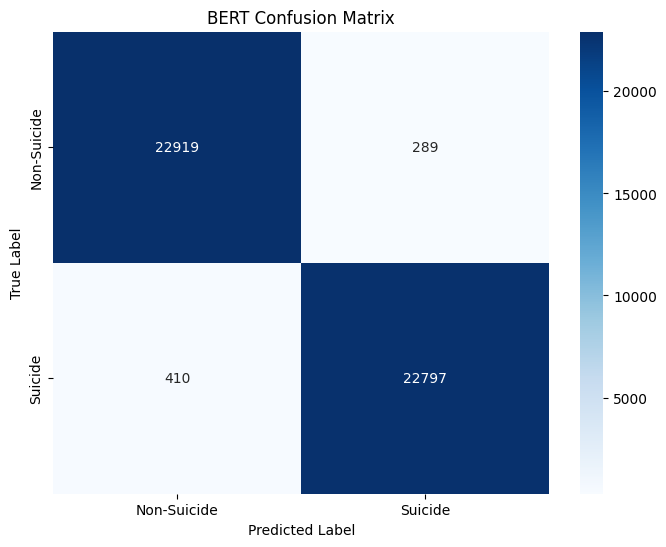

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the confusion matrix for BERT from the results dictionary
bert_conf_matrix = results["BERT"]["conf_matrix"]

plt.figure(figsize=(8, 6))
sns.heatmap(bert_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Suicide', 'Suicide'], yticklabels=['Non-Suicide', 'Suicide'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('BERT Confusion Matrix')
plt.show()

In [45]:
metrics_list = []
metrics_to_extract = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for model_name, model_results in results.items():
    model_metrics = {'Model': model_name}
    for metric in metrics_to_extract:
        # Ensure the value is not a numpy type for better display in DataFrame
        if isinstance(model_results[metric], np.float64) or isinstance(model_results[metric], np.float32):
            model_metrics[metric.replace('_', ' ').capitalize()] = float(model_results[metric])
        else:
            model_metrics[metric.replace('_', ' ').capitalize()] = model_results[metric]
    metrics_list.append(model_metrics)

performance_df = pd.DataFrame(metrics_list)

# Reorder columns to have 'Model' first
column_order = ['Model'] + [metric.replace('_', ' ').capitalize() for metric in metrics_to_extract]
performance_df = performance_df[column_order]

print("Consolidated Model Performance Metrics:")
performance_df

Consolidated Model Performance Metrics:


,Model,Accuracy,Precision,Recall,F1,Roc auc
0,Logistic Regression,0.860196,0.834654,0.898350,0.865332,0.920218
1,Random Forest,0.871270,0.897784,0.837937,0.866829,0.943773
2,K-Nearest Neighbors,0.790908,0.715880,0.964666,0.821858,0.890185
3,BERT,0.984940,0.987482,0.982333,0.984901,0.998727
